## LGC

In [13]:
class LCG:
    def __init__(self, seed, a, c, m):
        self.initial_state = seed
        self.state = seed
        self.a = a
        self.c = c
        self.m = m

    def next(self):
        self.state = (self.a * self.state + self.c) % self.m
        return self.state

    def find_period(self):
        seen_states = {}
        current_state = self.initial_state
        period = 0

        while current_state not in seen_states:
            seen_states[current_state] = period
            current_state = self.next()
            period += 1

        return period - seen_states[current_state]



## Example usage de LCG

In [12]:

seed = 42
a = 1664525
c = 101
m = 2**32
lcg = LCG(seed, a, c, m)
print(lcg.generate_numbers(10)) 


[1, 0, 1, 0, 1, 0, 1, 0, 1, 0]


## Examination de période de LGC

In [55]:
modulos = [i for i in range (2,100)] 
seed = 42
a = 110
c = 1
modulo_periods = []
for m in modulos:
    lcg = LCG(seed, a, c, m)
    period = lcg.find_period()
    modulo_periods.append((m, period))


modulo_periods.sort(key=lambda x: x[1], reverse=True)
for m, period in modulo_periods:
    print(f"Modulo {m}: Période {period}")


Modulo 97: Période 96
Modulo 81: Période 54
Modulo 89: Période 44
Modulo 49: Période 42
Modulo 98: Période 42
Modulo 83: Période 41
Modulo 41: Période 40
Modulo 82: Période 40
Modulo 79: Période 39
Modulo 31: Période 30
Modulo 61: Période 30
Modulo 62: Période 30
Modulo 93: Période 30
Modulo 59: Période 29
Modulo 53: Période 26
Modulo 47: Période 23
Modulo 94: Période 23
Modulo 67: Période 22
Modulo 69: Période 22
Modulo 43: Période 21
Modulo 86: Période 21
Modulo 27: Période 18
Modulo 54: Période 18
Modulo 71: Période 14
Modulo 87: Période 14
Modulo 13: Période 12
Modulo 26: Période 12
Modulo 39: Période 12
Modulo 52: Période 12
Modulo 65: Période 12
Modulo 78: Période 12
Modulo 91: Période 12
Modulo 23: Période 11
Modulo 46: Période 11
Modulo 92: Période 11
Modulo 73: Période 9
Modulo 17: Période 8
Modulo 34: Période 8
Modulo 51: Période 8
Modulo 68: Période 8
Modulo 85: Période 8
Modulo 29: Période 7
Modulo 58: Période 7
Modulo 7: Période 6
Modulo 9: Période 6
Modulo 14: Période 6
M

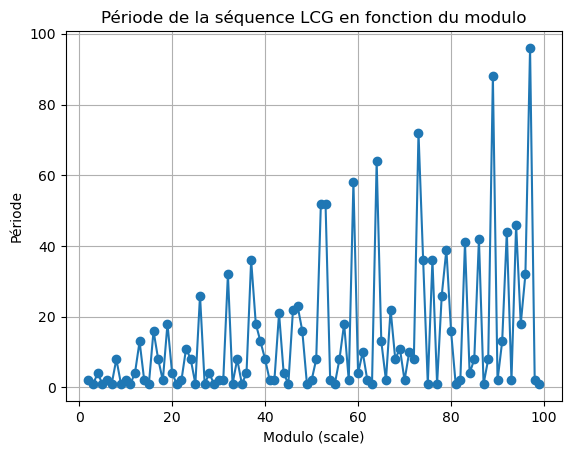

In [46]:
import matplotlib.pyplot as plt

modulos = [i for i in range (2,100)]  
seed = 42
a = 1103515245
c = 12345

plt.plot(modulos, periods, marker='o')
plt.xlabel('Modulo (scale)')
plt.ylabel('Période')
plt.title('Période de la séquence LCG en fonction du modulo')
plt.grid(True)
plt.show()


## Théorème de Hull-Dobell

In [49]:

from sympy import factorint

def is_hull_dobell_valid(a, c, m):
    if gcd(c, m) != 1:
        return False, "Condition 1 échouée : c et m ne sont pas premiers entre eux."
    factors = factorint(m)  
    for p in factors:
        if (a - 1) % p != 0:
            return False, f"Condition 2 échouée : a-1 n'est pas divisible par {p}."
    if m % 4 == 0 and (a - 1) % 4 != 0:
        return False, "Condition 3 échouée : a-1 n'est pas divisible par 4 alors que m est divisible par 4."

    return True, "Les paramètres respectent le théorème de Hull-Dobell."

## Exemple d'utlisisation et vérification de la période

In [52]:
is_hull_dobell_valid(21,4,19)

(False, "Condition 2 échouée : a-1 n'est pas divisible par 19.")

In [53]:
is_hull_dobell_valid(20,17,19)

(True, 'Les paramètres respectent le théorème de Hull-Dobell.')

In [56]:
lcg = LCG(27,20,17,19)
print(lcg.find_period())

19


In [57]:
lcg = LCG(27,21,4,19)
print(lcg.find_period())

18


###  CODE BBS

In [1]:
def is_prime(n):
    if n < 2:
        return False
    for i in range(2, int(n ** 0.5) + 1):
        if n % i == 0:
            return False
    return True

def is_blum_prime(p):
    return is_prime(p) and p % 4 == 3

def gcd(a, b):
    while b:
        a, b = b, a % b
    return a

class BBS:
    def __init__(self, p, q, seed):
        if not (is_blum_prime(p) and is_blum_prime(q)):
            raise ValueError("p and q must both be Blum primes (prime numbers congruent to 3 mod 4)")
        
        self.n = p * q
        
        if gcd(seed, self.n) != 1:
            raise ValueError("Seed must be coprime to n")
        
        self.state = (seed * seed) % self.n

    def next_bit(self):
        self.state = (self.state * self.state) % self.n
        return self.state % 2

    def generate_bits(self, num_bits):
        return [self.next_bit() for _ in range(num_bits)]


## EXEMPLE D'UTILISATION DE BBS

In [58]:
p = 11
q = 19
seed = 3

bbs = BBS(p, q, seed)
print(bbs.generate_bits(10))  
 

[1, 0, 0, 0, 0, 0, 1, 0, 1, 1]


In [71]:
import math

def multiplicative_order(n, a):
    if gcd(a, n) != 1:
        return None  
    phi = n  
    factors = []
    temp_phi = phi
    d = 2
    while d * d <= temp_phi:
        if temp_phi % d == 0:
            factors.append(d)
            while temp_phi % d == 0:
                temp_phi //= d
        d += 1
    if temp_phi > 1:
        factors.append(temp_phi)

    def is_order(k):
        return pow(a, k, n) == 1

    for k in range(1, phi + 1):
        if is_order(k):
            return k
    return None

def bbs_period(p, q, s):
    """Calculates the period of the BBS generator given p, q, and s."""
    n = p * q

    if gcd(s, n) != 1:
        raise ValueError("The seed 's' must be coprime with 'n'.")

    order_s = multiplicative_order(n, s)
    if order_s is None:
        raise ValueError("Could not calculate the multiplicative order of 's' modulo 'n'. This should not happen if gcd(s, n) == 1.")

    # The period T is the smallest positive integer such that 2^T = 1 (mod order_s / gcd(2, order_s))
    # Or, more directly, find the smallest T such that s**(2**T) % n == s**2 % n

    seen_values = {}
    current_value = pow(s, 2, n)
    sequence = [current_value]
    seen_values[current_value] = 0

    for i in range(1, n + 2): # Iterate at most n+1 times to detect the cycle
        next_value = pow(current_value, 2, n)
        if next_value in seen_values:
            return i - seen_values[next_value]
        seen_values[next_value] = i
        sequence.append(next_value)
        current_value = next_value

    return None # Should not happen in theory for a valid BBS

# Example usage:
p = 9
q =  39
s = 20

try:
    period = bbs_period(p, q, s)
    print(f"The period of the BBS generator with p={p}, q={q}, and s={s} is: {period}")
except ValueError as e:
    print(f"Error: {e}")

The period of the BBS generator with p=9, q=39, and s=20 is: 6


In [60]:
bbs_period(23, 47, 1080)

1